In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
from SALib.analyze import morris as morris_analyze
from SALib.analyze import sobol as sobol_analyze
from SALib.sample import morris as morris_sample
from SALib.sample import sobol as sobol_sampler

from common.config import REPO_ROOT, SALIB_PROBLEM
from common.sensitivity import evaluate_ode, evaluate_pde, plot_morris, plot_sobol

FIG_DIR = REPO_ROOT / "presentation" / "figures"
T_END = 5.0
DT = 1e-2
NX = 50


In [2]:
values = morris_sample.sample(SALIB_PROBLEM, N=20, num_levels=4, optimal_trajectories=10)

print("Morris analysis for the ODE model...")
Si_ode_morris = morris_analyze.analyze(SALIB_PROBLEM, values, evaluate_ode(values, NX, T_END), conf_level=0.95)

print("Morris analysis for the PDE model...")
Si_pde_morris = morris_analyze.analyze(SALIB_PROBLEM, values, evaluate_pde(values, NX, DT, T_END), conf_level=0.95)

print("Morris analysis done.")


Morris analysis for the ODE model...
Morris analysis for the PDE model...
PDE evaluation: 20/40
PDE evaluation: 40/40
Morris analysis done.


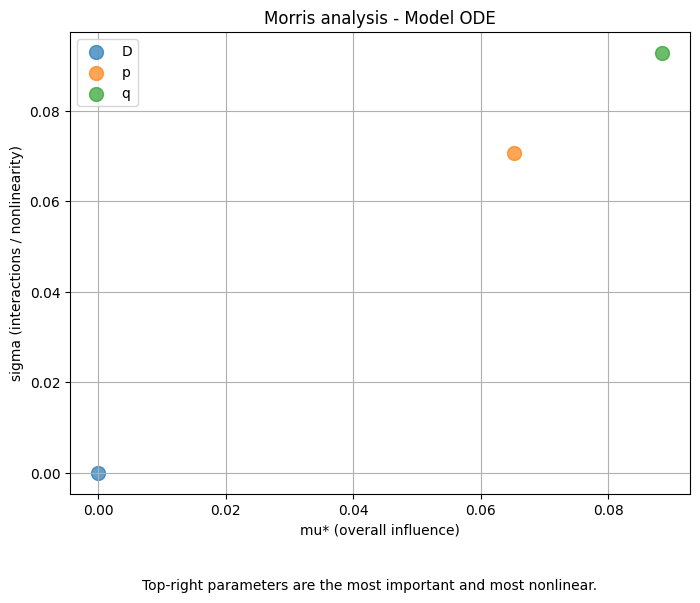

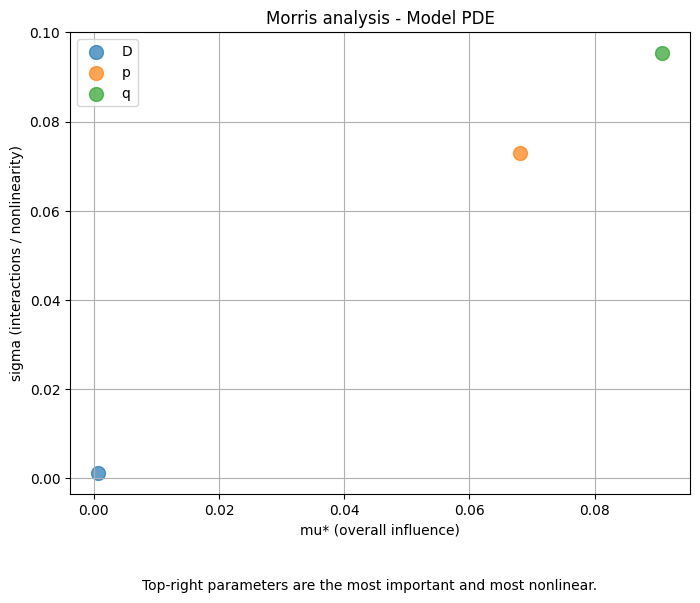

In [3]:
plot_morris(Si_ode_morris, "Model ODE", tag="model_ode", fig_dir=FIG_DIR)
plot_morris(Si_pde_morris, "Model PDE", tag="model_pde", fig_dir=FIG_DIR)


In [4]:
values = sobol_sampler.sample(SALIB_PROBLEM, N=128)

print(f"Sobol analysis for the ODE model ({values.shape[0]} evaluations)...")
Si_ode_sobol = sobol_analyze.analyze(SALIB_PROBLEM, evaluate_ode(values, NX, T_END), print_to_console=True)

print(f"Sobol analysis for the PDE model ({values.shape[0]} evaluations)...")
Si_pde_sobol = sobol_analyze.analyze(SALIB_PROBLEM, evaluate_pde(values, NX, DT, T_END), print_to_console=True)

print("Sobol analysis done.")


Sobol analysis for the ODE model (1024 evaluations)...
         ST   ST_conf
D  0.000000  0.000000
p  0.296575  0.146918
q  0.643453  0.367910
        S1   S1_conf
D  0.00000  0.000000
p  0.06308  0.250501
q  0.56676  0.271692
                  S2       S2_conf
(D, p) -2.775558e-17  6.571341e-17
(D, q)  0.000000e+00  1.232289e-16
(p, q)  2.595583e-01  5.119797e-01
Sobol analysis for the PDE model (1024 evaluations)...
PDE evaluation: 20/1024
PDE evaluation: 40/1024
PDE evaluation: 60/1024
PDE evaluation: 80/1024
PDE evaluation: 100/1024
PDE evaluation: 120/1024
PDE evaluation: 140/1024
PDE evaluation: 160/1024
PDE evaluation: 180/1024
PDE evaluation: 200/1024
PDE evaluation: 220/1024
PDE evaluation: 240/1024
PDE evaluation: 260/1024
PDE evaluation: 280/1024
PDE evaluation: 300/1024
PDE evaluation: 320/1024
PDE evaluation: 340/1024
PDE evaluation: 360/1024
PDE evaluation: 380/1024
PDE evaluation: 400/1024
PDE evaluation: 420/1024
PDE evaluation: 440/1024
PDE evaluation: 460/1024
PDE eva

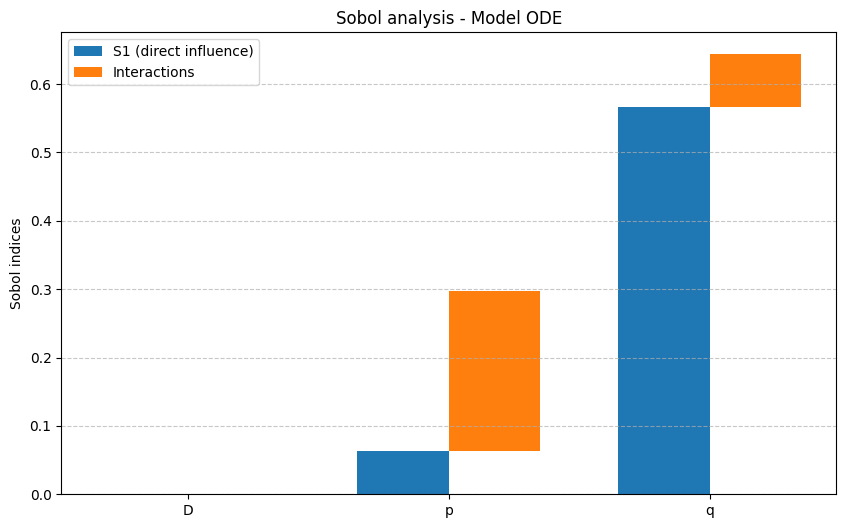

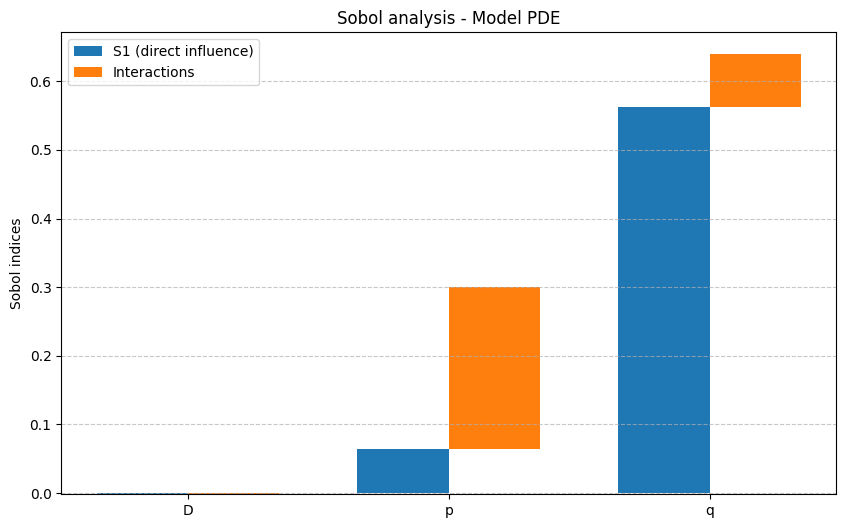

In [5]:
plot_sobol(Si_ode_sobol, "Model ODE", tag="model_ode", fig_dir=FIG_DIR)
plot_sobol(Si_pde_sobol, "Model PDE", tag="model_pde", fig_dir=FIG_DIR)
